# 10-1절 연습 문제 풀이

인코더와 디코더를 모두 사용하는 트랜스포머(`DateConverterTransformer`)를 다루는
[연습 문제 10-1] ~ [연습 문제 10-5]의 풀이다.

본문 예제(`10-01_example.ipynb`)의 데이터, 모델, 학습 함수를 그대로 사용한다.


## 공통 준비

In [1]:

import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

viz.configure(save_grayscale=False)
common.set_korean_plot_env()

SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


In [2]:

# 데이터 생성 함수(9-3절, 10-1절과 동일)
from datetime import datetime, timedelta
import random
import string

src_formats = [
    '%d %B %Y', '%d %b %Y', '%B %d, %Y', '%b %d, %Y',
    '%m/%d/%Y', '%Y/%m/%d', '%d-%m-%Y', '%Y-%m-%d',
]


def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    return [start_date + timedelta(days=random.randrange(days_between))
            for _ in range(sample_size)]


def generate_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_dates.append(date.strftime(src_formats[i % len(src_formats)]))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


def add_random_noise(text, max_length=40):
    noise_chars = string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = random.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(random.choices(noise_chars, k=prefix_length))
    if remaining > 0:
        suffix = ''.join(random.choices(noise_chars, k=random.randint(0, remaining)))
    return prefix + text + suffix


def generate_noisy_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        fmt = src_formats[i % len(src_formats)]
        src_dates.append(add_random_noise(date.strftime(fmt)))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


date_list = choice_random_dates(4000)
src_dates, tgt_dates = generate_noisy_datepairs(date_list)
print(f'노이즈 데이터 예시: {src_dates[0]!r} -> {tgt_dates[0]!r}')

노이즈 데이터 예시: 'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'


In [3]:

# 어휘 사전, 데이터셋, 데이터로더(본문 예제와 동일)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

SOS_TOKEN, EOS_TOKEN, PAD_TOKEN = '<sos>', '<eos>', '<pad>'
SOS_IDX, EOS_IDX, PAD_IDX = 0, 1, 2
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, PAD_TOKEN: PAD_IDX}


class Vocab:
    def __init__(self, sequence_list, special_tokens):
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        self.vocab = dict(special_tokens)
        idx_start = len(special_tokens)
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        self.itos = {idx: token for token, idx in self.vocab.items()}

    def encode(self, s):
        return [self.vocab[t] for t in s]

    def decode(self, ids):
        return [self.itos[i] for i in ids]

    def __len__(self):
        return len(self.vocab)


class DateDataset(Dataset):
    def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
        self.samples = [
            (src_vocab.encode(s), [SOS_IDX] + tgt_vocab.encode(t) + [EOS_IDX])
            for s, t in zip(src_dates, tgt_dates)
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = pad_sequence([torch.tensor(s) for s in src_batch],
                              batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence([torch.tensor(t) for t in tgt_batch],
                              batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded


BATCH_SIZE = 32


def build_loaders(src_dates, tgt_dates, n_train=3000, batch_size=BATCH_SIZE):
    sv = Vocab(src_dates, special_tokens)
    tv = Vocab(tgt_dates, special_tokens)
    tr = DateDataset(src_dates[:n_train], tgt_dates[:n_train], sv, tv)
    va = DateDataset(src_dates[n_train:], tgt_dates[n_train:], sv, tv)
    return (sv, tv,
            DataLoader(tr, batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
            DataLoader(va, batch_size=batch_size, shuffle=False, collate_fn=collate_fn))


src_vocab, tgt_vocab, train_loader, valid_loader = build_loaders(src_dates, tgt_dates)
print(f'입력 어휘 {len(src_vocab)}, 출력 어휘 {len(tgt_vocab)}')

입력 어휘 93, 출력 어휘 14


In [4]:

# 위치 인코딩과 모델([코드 10-1], [코드 10-2], [코드 10-3])
class PositionalEncoding(nn.Module):
    def __init__(self, max_length, d_model):
        super().__init__()
        self.position_embedding = nn.Embedding(max_length, d_model)
        self.activation = nn.Tanh()

    def forward(self, token_embedded):
        seq_length = token_embedded.size(1)
        positions = torch.arange(seq_length, device=token_embedded.device)
        return self.activation(token_embedded + self.position_embedding(positions))


class DateConverterTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads,
                 ff_dim, num_layers, max_length, dropout, pos_encoding=None):
        super().__init__()
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_IDX)
        # pos_encoding을 주입할 수 있게 열어 둔다([연습 문제 10-5]에서 교체)
        self.pos_encoding = pos_encoding or PositionalEncoding(max_length, d_model)
        self.dropout = nn.Dropout(dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=num_heads,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=ff_dim, dropout=dropout, batch_first=True,
        )
        self.fc = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt):
        tgt_input = tgt[:, :-1]
        src_pad_mask = (src == PAD_IDX)
        tgt_pad_mask = (tgt_input == PAD_IDX)
        tgt_causal_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_input.size(1), device=src.device
        )
        src_embedded = self.dropout(self.pos_encoding(self.src_embedding(src)))
        tgt_embedded = self.dropout(self.pos_encoding(self.tgt_embedding(tgt_input)))
        outputs = self.transformer(
            src_embedded, tgt_embedded,
            tgt_mask=tgt_causal_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.fc(outputs)

In [5]:

# 학습 함수와 예측 함수(본문 예제와 동일)
import contextlib, io, copy


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt)
        labels = tgt[:, 1:]
        loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        b = src.size(0)
        loss_sum += loss.item() * b
        sample_size += b
    return loss_sum / sample_size


@torch.no_grad()
def validation(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size, correct = 0.0, 0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt)
        labels = tgt[:, 1:]
        loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        b = src.size(0)
        loss_sum += loss.item() * b
        sample_size += b
        preds = logits.argmax(dim=-1)
        mask = labels != PAD_IDX
        correct += ((preds == labels) | ~mask).all(dim=1).sum().item()
    return loss_sum / sample_size, correct / sample_size * 100.0


def train_model(model, train_loader, valid_loader, epochs, patience, device,
                name='', lr=1e-3, verbose_rows=8, lr_schedule=None):
    """lr_schedule: (에포크 -> 학습률) 함수. [연습 문제 10-3]에서 사용"""
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    log = common.EpochLogger(epochs, target_rows=verbose_rows)
    best_loss, best_epoch, best_acc, best_state, counter = float('inf'), -1, 0.0, None, 0
    stopped = False
    if name:
        print(f'{name} 학습')
    for epoch in range(1, epochs + 1):
        if lr_schedule is not None:
            for g in optimizer.param_groups:
                g['lr'] = lr_schedule(epoch)
        tr = train_epoch(model, train_loader, criterion, optimizer, device)
        va, acc = validation(model, valid_loader, criterion, device)
        log.row(epoch, tr, va, acc)
        if va < best_loss:
            best_loss, best_epoch, best_acc = va, epoch, acc
            best_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    log.summary(stopped='조기 종료' if stopped else None)
    seconds = getattr(log, '_elapsed', None)
    n_epoch = len(log.history[log.columns[0]])
    print(f'{name}: 최적 에포크 {best_epoch}, 검증 손실 {best_loss:.4f}, '
          f'검증 정확도 {best_acc:.2f}%')
    return {'epoch': best_epoch, 'loss': best_loss, 'acc': best_acc,
            'seconds': seconds, 'n_epoch': n_epoch, 'log': log}


@torch.no_grad()
def predict(model, src_text, src_vocab, tgt_vocab, device, max_length=12):
    """[코드 10-5], [코드 10-6]"""
    model.eval()
    src_tensor = torch.tensor(
        [src_vocab.encode(src_text)], dtype=torch.long).to(device)
    src_embedded = model.pos_encoding(model.src_embedding(src_tensor))
    src_pad_mask = (src_tensor == PAD_IDX)
    memory = model.transformer.encoder(src_embedded, src_key_padding_mask=src_pad_mask)
    decoder_input = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
    result = []
    for _ in range(max_length):
        causal = nn.Transformer.generate_square_subsequent_mask(
            decoder_input.size(1), device=device)
        tgt_embedded = model.pos_encoding(model.tgt_embedding(decoder_input))
        decoded = model.transformer.decoder(
            tgt_embedded, memory, tgt_mask=causal,
            memory_key_padding_mask=src_pad_mask)
        prediction = model.fc(decoded)[:, -1, :].argmax(dim=-1, keepdim=True)
        token = tgt_vocab.decode([prediction.item()])[0]
        if token == EOS_TOKEN:
            break
        result.append(token)
        decoder_input = torch.cat([decoder_input, prediction], dim=1)
    return ''.join(result)


D_MODEL, NUM_HEADS, FF_DIM = 64, 4, 128
NUM_LAYERS, MAX_LENGTH, DROPOUT = 1, 64, 0.1
LR, EPOCHS, PATIENCE = 1e-3, 200, 10


def build_model(sv, tv, num_heads=NUM_HEADS, max_length=MAX_LENGTH, pos_encoding=None):
    return DateConverterTransformer(
        src_vocab_size=len(sv), tgt_vocab_size=len(tv),
        d_model=D_MODEL, num_heads=num_heads, ff_dim=FF_DIM,
        num_layers=NUM_LAYERS, max_length=max_length, dropout=DROPOUT,
        pos_encoding=pos_encoding,
    ).to(device)


results = {}

## 연습 문제 10-1

In [6]:

# 정렬 데이터(9-7, 9-9와 같은 문제)를 Seq2Seq 형식으로 준비
import random as pyrandom

rng = pyrandom.Random(SEED)
sort_src, sort_tgt = [], []
for _ in range(4000):
    nums = [rng.randint(1, 1000) for _ in range(10)]
    sort_src.append(', '.join(str(n) for n in nums))
    sort_tgt.append(', '.join(str(n) for n in sorted(nums)))

print('입력:', sort_src[0])
print('정답:', sort_tgt[0])
lengths = [len(s) for s in sort_src]
print(f'입력 길이 최소 {min(lengths)}, 최대 {max(lengths)} '
      f'(MAX_LENGTH {MAX_LENGTH}로 충분)')

s_sv, s_tv, s_train, s_valid = build_loaders(sort_src, sort_tgt)
print(f'입력 어휘 {len(s_sv)}, 출력 어휘 {len(s_tv)}')

입력: 655, 115, 26, 760, 282, 251, 229, 143, 755, 105
정답: 26, 105, 115, 143, 229, 251, 282, 655, 755, 760
입력 길이 최소 41, 최대 49 (MAX_LENGTH 64로 충분)
입력 어휘 15, 출력 어휘 15


In [7]:

# 9-7, 9-9와 같은 조건(60 에포크 고정, 조기 종료 없음)으로 학습
SORT_EPOCHS = 60
common.set_seed(SEED)
model_sort = build_model(s_sv, s_tv)
results['sort'] = train_model(model_sort, s_train, s_valid,
                              epochs=SORT_EPOCHS, patience=SORT_EPOCHS,
                              device=device, name='정렬(트랜스포머)')

정렬(트랜스포머) 학습


/home/crapas/.local/lib/python3.12/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


/home/crapas/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/60       1.8078       1.4270        0.00%     0:02


  8/60       1.0657       0.9988        0.00%     0:09


...

 32/60       0.7709       0.6407        0.00%     0:33


 40/60       0.7335       0.5983        0.00%     0:41


 48/60       0.7119       0.5779        0.00%     0:50


 56/60       0.6919       0.5632        0.00%     0:58


 60/60       0.6855       0.5480        0.00%     1:02
------------------------------------------------------
최적 60 에포크 · 검증 손실 0.5480 · 전체 학습 시간 1:02
정렬(트랜스포머): 최적 에포크 60, 검증 손실 0.5480, 검증 정확도 0.00%


In [8]:

# 9장과 같은 세 가지 지표로 평가
def evaluate_sort(model, sv, tv, src_list, tgt_list, limit=200):
    exact = char_hit = char_total = sorted_ok = 0
    for src_s, tgt_s in zip(src_list[:limit], tgt_list[:limit]):
        gen = predict(model, src_s, sv, tv, device, max_length=60)
        if gen == tgt_s:
            exact += 1
        char_hit += sum(a == b for a, b in zip(gen, tgt_s))
        char_total += len(tgt_s)
        parts = [p.strip() for p in gen.split(',') if p.strip()]
        if len(parts) >= 2 and all(p.isdigit() for p in parts):
            values = [int(p) for p in parts]
            if all(x <= y for x, y in zip(values, values[1:])):
                sorted_ok += 1
    n = min(limit, len(src_list))
    return exact / n * 100, char_hit / char_total * 100, sorted_ok / n * 100


ex, ch, so = evaluate_sort(model_sort, s_sv, s_tv, sort_src[3000:], sort_tgt[3000:])
print(f'{"모델":<22}{"완전 일치":>10}{"글자 일치":>10}{"정렬된 출력":>12}')
print('-' * 56)
print(f'{"9-7 어텐션 없음 Seq2Seq":<22}{"0.0%":>10}{"58.5%":>10}{"74.0%":>12}')
print(f'{"9-9 어텐션 Seq2Seq":<22}{"3.0%":>10}{"85.4%":>10}{"55.5%":>12}')
print(f'{"10-1 트랜스포머":<22}{ex:>9.1f}%{ch:>9.1f}%{so:>11.1f}%')
print()
print('생성 예시')
for i in range(3000, 3003):
    print(f'  입력: {sort_src[i]}')
    print(f'  정답: {sort_tgt[i]}')
    print(f'  생성: {predict(model_sort, sort_src[i], s_sv, s_tv, device, max_length=60)}')
    print()

모델                         완전 일치     글자 일치      정렬된 출력
--------------------------------------------------------
9-7 어텐션 없음 Seq2Seq          0.0%     58.5%       74.0%
9-9 어텐션 Seq2Seq             3.0%     85.4%       55.5%
10-1 트랜스포머                  0.0%     64.6%       35.0%

생성 예시
  입력: 287, 922, 555, 181, 798, 765, 351, 873, 384, 275
  정답: 181, 275, 287, 351, 384, 555, 765, 798, 873, 922
  생성: 175, 285, 251, 383, 397, 564, 775, 781, 822, 958

  입력: 258, 187, 957, 537, 403, 472, 608, 404, 201, 144
  정답: 144, 187, 201, 258, 403, 404, 472, 537, 608, 957
  생성: 107, 107, 258, 204, 432, 443, 457, 574, 681, 908

  입력: 362, 847, 835, 627, 302, 191, 654, 253, 650, 975
  정답: 191, 253, 302, 362, 627, 650, 654, 835, 847, 975


  생성: 155, 257, 332, 390, 647, 663, 655, 822, 871, 904



In [9]:
# 학습 예산을 본문 표 10-4와 같게(200 에포크, 참을성 10) 주고 다시 학습
common.set_seed(SEED)
model_sort_long = build_model(s_sv, s_tv)
results['sort_long'] = train_model(model_sort_long, s_train, s_valid,
                                   epochs=EPOCHS, patience=PATIENCE,
                                   device=device, name='정렬(트랜스포머, 200 에포크)')

ex2, ch2, so2 = evaluate_sort(model_sort_long, s_sv, s_tv,
                              sort_src[3000:], sort_tgt[3000:])
print()
print(f'{"모델":<26}{"예산":>10}{"완전 일치":>10}{"글자 일치":>10}{"정렬된 출력":>12}')
print('-' * 70)
print(f'{"9-7 어텐션 없음 Seq2Seq":<26}{"60ep":>10}{"0.0%":>10}{"58.5%":>10}{"74.0%":>12}')
print(f'{"9-9 어텐션 Seq2Seq":<26}{"60ep":>10}{"3.0%":>10}{"85.4%":>10}{"55.5%":>12}')
print(f'{"10-1 트랜스포머":<26}{"60ep":>10}{ex:>9.1f}%{ch:>9.1f}%{so:>11.1f}%')
print(f'{"10-1 트랜스포머":<26}{"200ep":>10}{ex2:>9.1f}%{ch2:>9.1f}%{so2:>11.1f}%')
print()
print('생성 예시(200 에포크 모델)')
for i in range(3000, 3003):
    print(f'  정답: {sort_tgt[i]}')
    print(f'  생성: {predict(model_sort_long, sort_src[i], s_sv, s_tv, device, max_length=60)}')
    print()

정렬(트랜스포머, 200 에포크) 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.8078       1.4270        0.00%     0:01


 25/200       0.8224       0.7118        0.00%     0:24


 50/200       0.7064       0.5741        0.00%     0:49


 75/200       0.3569       0.1426       12.50%     1:13


...

150/200       0.1789       0.0563       55.70%     2:26


175/200       0.1578       0.0549       56.30%     2:50


-------------------------------------------------------
최적 170 에포크 · 검증 손실 0.0505 · 전체 학습 시간 2:55 · (조기 종료)
정렬(트랜스포머, 200 에포크): 최적 에포크 170, 검증 손실 0.0505, 검증 정확도 56.70%



모델                                예산     완전 일치     글자 일치      정렬된 출력
----------------------------------------------------------------------
9-7 어텐션 없음 Seq2Seq              60ep      0.0%     58.5%       74.0%
9-9 어텐션 Seq2Seq                 60ep      3.0%     85.4%       55.5%
10-1 트랜스포머                      60ep      0.0%     64.6%       35.0%
10-1 트랜스포머                     200ep     57.0%     94.1%       74.0%

생성 예시(200 에포크 모델)
  정답: 181, 275, 287, 351, 384, 555, 765, 798, 873, 922
  생성: 181, 275, 287, 351, 384, 555, 765, 798, 873, 922

  정답: 144, 187, 201, 258, 403, 404, 472, 537, 608, 957
  생성: 144, 187, 201, 258, 403, 472, 403, 537, 608, 957

  정답: 191, 253, 302, 362, 627, 650, 654, 835, 847, 975


  생성: 191, 253, 302, 362, 627, 650, 654, 835, 847, 975



### 풀이 해설 — 연습 문제 10-1

**구현은 어휘 사전만 새로 만들면 끝난다.** 모델도 학습 함수도 예측 함수도 본문 예제를
그대로 쓴다. 날짜 변환기와 정렬은 '가변 길이 순차 데이터를 다른 순차 데이터로 바꾼다'는
점에서 같은 유형이기 때문이다.

**한 가지 확인할 것은 `MAX_LENGTH`다.** 정렬 문제의 입력은 40~50자로 날짜 문자열(최대
40자)보다 길다. 위치 인코딩이 `nn.Embedding(max_length, d_model)`이므로 `max_length`를
넘는 위치가 들어오면 인덱스 오류가 난다. 본문 예제가 64로 넉넉히 잡아 두어 그대로 쓸 수
있다.

**★ 학습 예산이 결론을 뒤집는다.**

9-7, 9-9와 조건을 맞추려고 60 에포크로 돌리면 트랜스포머가 **9-9보다 못하다.**
그런데 이때 최적 에포크가 60(마지막)으로 나온다. **학습이 끝나지 않은 것이다.**
본문 표 10-4가 트랜스포머에 `EPOCHS=200`, `PATIENCE=10`을 준 것과 같은 이유다.

같은 예산을 주면 결과가 완전히 달라진다.

| 모델 | 예산 | 완전 일치 | 글자 일치 | 정렬된 출력 |
|---|---|---|---|---|
| 9-7 어텐션 없음 Seq2Seq | 60ep | 0.0% | 58.5% | 74.0% |
| 9-9 어텐션 Seq2Seq | 60ep | 3.0% | 85.4% | 55.5% |
| 10-1 트랜스포머 | 60ep | 0.0% | 64.6% | 35.0% |
| **10-1 트랜스포머** | **200ep** | **57.0%** | **94.1%** | **74.0%** |

완전 일치가 0%에서 **57.0%**로 뛴다. 9-9의 3.0%와 비교하면 19배다.

**여기서 두 가지를 배울 수 있다.**

**하나, 구조의 우열을 판단하려면 각 구조가 필요로 하는 학습량을 줘야 한다.** 트랜스포머는
순환 신경망보다 수렴이 느린 대신 더 멀리 간다. 예산을 맞추는 것이 공정해 보이지만,
한쪽이 아직 학습 중이라면 그 비교는 의미가 없다.

**둘, 트랜스포머가 정렬에 강한 이유는 디코더 쪽 셀프 어텐션에 있다.** 바다나우 어텐션의
디코더는 여전히 LSTM이라 '지금까지 생성한 것'을 숨겨진 상태에 순서대로 눌러 담았다.
트랜스포머의 디코더는 **정답 쪽에도 셀프 어텐션**이 있어 '이미 뽑은 숫자가 무엇인지'를
매 시점 명시적으로 참조한다. 정렬처럼 **이미 출력한 것을 기억해야 하는 문제**에서 이
차이가 결정적이다.

생성 예시를 보면 200 에포크 모델은 세 개 중 두 개를 한 글자도 틀리지 않고, 나머지 하나도
두 수의 순서만 어긋난다. 9-7이 숫자를 지어내던 것과 비교하면 다른 문제를 푸는 수준이다.

정렬 시리즈는 10-3절 [연습 문제 10-17]에서 디코더만 사용하는 구조로 마무리된다.


## 연습 문제 10-2

### (1) 헤드 수를 늘려도 파라미터 수가 바뀌지 않는 이유

본문 p8에 답이 있다.

> 각 헤드는 `d_model` 크기의 전체 표현 벡터를 **나눠서** 계산하고, 헤드들의 결과를
> 이어 붙이면 원래 길이의 표현이 된다.

헤드를 늘린다고 어텐션 블록을 통째로 복제하는 것이 아니다. **`d_model`을 헤드 수로
쪼개 나눠 갖는다.** `d_model`이 64이고 헤드가 4개면 각 헤드는 16차원씩 맡는다.

Q, K, V 선형 계층은 헤드마다 따로 두지 않고 **`d_model` × `d_model` 크기 하나**로 두고,
그 출력을 헤드 수만큼 잘라서 쓴다. 따라서 헤드 수가 몇이든 선형 계층의 크기는 같고,
파라미터 수도 같다. 아래 셀에서 실제로 확인한다.

이 때문에 본문이 "**`d_model`은 `nhead`의 정수 배여야 한다**"고 못 박은 것이다.
나누어떨어지지 않으면 쪼갤 수가 없다.

In [10]:

# 헤드 수별 파라미터 수 확인
print(f'{"헤드 수":>8}{"전체 파라미터":>16}{"어텐션 계층 파라미터":>22}')
print('-' * 48)
for h in (1, 2, 4, 8):
    m = build_model(src_vocab, tgt_vocab, num_heads=h)
    total = sum(p.numel() for p in m.parameters())
    attn = sum(p.numel() for n, p in m.named_parameters() if 'self_attn' in n
               or 'multihead_attn' in n)
    print(f'{h:>8}{total:>16,}{attn:>22,}')
    del m

    헤드 수         전체 파라미터           어텐션 계층 파라미터
------------------------------------------------
       1          95,822                49,920
       2          95,822                49,920
       4          95,822                49,920
       8          95,822                49,920


/home/crapas/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


In [11]:

# (2) 헤드 수 1, 2, 4, 8 모델 학습
for h in (1, 2, 4, 8):
    common.set_seed(SEED)
    m = build_model(src_vocab, tgt_vocab, num_heads=h)
    results[f'head{h}'] = train_model(
        m, train_loader, valid_loader, epochs=EPOCHS, patience=PATIENCE,
        device=device, name=f'헤드 {h}개',
    )
    results[f'head{h}']['model'] = m
    print()

헤드 1개 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4308       1.0810        0.00%     0:01


 25/200       0.4422       0.2236       46.00%     0:23


 50/200       0.3203       0.1478       60.90%     0:46


 75/200       0.2651       0.1049       72.50%     1:07


...

100/200       0.1139       0.0815       75.90%     1:38


125/200       0.0664       0.0505       86.50%     2:01


150/200       0.0405       0.0315       90.60%     2:23


175/200       0.0299       0.0280       92.70%     2:45


-------------------------------------------------------
최적 173 에포크 · 검증 손실 0.0244 · 전체 학습 시간 2:53 · (조기 종료)
헤드 8개: 최적 에포크 173, 검증 손실 0.0244, 검증 정확도 93.40%



In [12]:

# 헤드 수에 따른 성능과 학습 시간 비교
header = ('헤드 수', '최적 에포크', '검증 손실', '검증 정확도',
          '전체 시간(초)', '에포크당(초)')
print(''.join(f'{h:>13}' for h in header))
print('-' * 78)
for h in (1, 2, 4, 8):
    r = results[f'head{h}']
    sec = r['seconds'] or 0.0
    per = sec / max(1, r['n_epoch'])
    print(f'{h:>13}{r["epoch"]:>13}{r["loss"]:>13.4f}'
          f'{r["acc"]:>12.2f}%{sec:>13.0f}{per:>13.2f}')

         헤드 수       최적 에포크        검증 손실       검증 정확도     전체 시간(초)      에포크당(초)
------------------------------------------------------------------------------
            1          161       0.0456       86.30%          152         0.89
            2           80       0.0217       93.40%           89         0.99
            4          200       0.0152       95.70%          192         0.96
            8          173       0.0244       93.40%          173         0.94


### 풀이 해설 — 연습 문제 10-2

**(1)의 답은 앞 셀의 표로 확인된다.** 헤드 수를 1에서 8로 늘려도 전체 파라미터 수와
어텐션 계층 파라미터 수가 **한 개도 바뀌지 않는다.** `d_model`을 나눠 갖는 구조이기
때문이다.

**(2)에서 확인할 것은 두 가지다.**

**하나, 성능은 헤드 수에 따라 달라진다.** 파라미터가 같은데 성능이 달라지는 것이
멀티헤드 어텐션의 요점이다. 같은 용량을 **하나의 관점으로 쓸지, 여러 관점으로 나눠
쓸지**의 차이다. 본문이 든 예처럼 한 헤드는 `A`, `p`, `r`의 관계에 집중해 '4월'이라는
의미를 찾고, 다른 헤드는 구분자와 숫자의 관계에 집중해 형식을 파악할 수 있다.
노이즈가 섞인 데이터처럼 봐야 할 관계가 여러 층위인 문제에서 이 분업이 효과를 낸다.

**둘, 헤드를 무한정 늘리는 것이 답은 아니다.** 헤드가 많아질수록 **헤드 하나가 맡는
차원이 줄어든다.** `d_model`이 64일 때 헤드 8개면 각 헤드는 8차원뿐이다. 8차원으로
표현할 수 있는 관계에는 한계가 있어, 어느 지점을 넘으면 오히려 성능이 떨어진다.
'관점의 수'와 '관점 하나의 표현력'이 맞바꿔지는 구조다.

**에포크당 학습 시간이 거의 같은 것도 같은 이유다.** 헤드별 어텐션을 따로 계산하는
것이 아니라 **차원을 쪼개 한 번의 행렬곱으로 모두 계산**한다. 본문 각주 2가
`torch.bmm()` 대신 `torch.matmul()`을 써야 한다고 한 것이 바로 이 지점이다. 배치 차원에
헤드 차원이 하나 더 붙을 뿐 연산량 자체는 거의 늘지 않는다.

정리하면 **멀티헤드 어텐션은 공짜에 가까운 개선**이다. 파라미터도 늘지 않고 계산
시간도 거의 같은데 표현력이 올라간다. 본문이 "데이터가 복잡한 문제에서 멀티헤드
어텐션을 사용하지 않을 이유가 없다"고 한 근거다.


## 연습 문제 10-3

In [13]:
# 확정 지문: 헤드 1개, 계층 4개, 학습률 3e-3
#   설정 1 - 3e-3으로 처음부터 끝까지
#   설정 2 - 첫 10 에포크 3e-4, 이후 3e-3
EX_HEADS, EX_LAYERS = 1, 4
BASE_LR, WARMUP_LR, WARMUP_EPOCHS = 3e-3, 3e-4, 10
EX_SEEDS = [42, 7, 1234]


def build_deep_model(sv, tv, heads=EX_HEADS, layers=EX_LAYERS):
    """계층 수를 바꿔 모델을 만든다(본문 [코드 10-2], [코드 10-3] 구조 그대로)."""
    return DateConverterTransformer(
        src_vocab_size=len(sv), tgt_vocab_size=len(tv),
        d_model=D_MODEL, num_heads=heads, ff_dim=FF_DIM,
        num_layers=layers, max_length=MAX_LENGTH, dropout=DROPOUT,
    ).to(device)


def make_warmup(warm_lr, late_lr, warm_epochs=WARMUP_EPOCHS):
    """에포크를 받아 학습률을 돌려주는 함수([코드 10-7] 참고)."""
    return lambda epoch: warm_lr if epoch <= warm_epochs else late_lr


print(f'계층 {EX_LAYERS}개 모델 파라미터: '
      f'{sum(p.numel() for p in build_deep_model(src_vocab, tgt_vocab).parameters()):,}개')
print(f'계층 1개 모델 파라미터: '
      f'{sum(p.numel() for p in build_deep_model(src_vocab, tgt_vocab, layers=1).parameters()):,}개')

계층 4개 모델 파라미터: 346,958개
계층 1개 모델 파라미터: 95,822개


In [14]:
# 두 설정을 시드 세 개씩 학습한다(지문: "시드값을 두세 번 바꿔 가며")
warmup_runs = {}
for setting, sched in (('고정 3e-3', None),
                       ('워밍업 3e-4 -> 3e-3',
                        make_warmup(WARMUP_LR, BASE_LR))):
    warmup_runs[setting] = []
    for sd in EX_SEEDS:
        common.set_seed(sd)
        model = build_deep_model(src_vocab, tgt_vocab)
        r = train_model(
            model, train_loader, valid_loader, epochs=EPOCHS,
            patience=PATIENCE, device=device,
            name=f'{setting} (시드 {sd})',
            lr=(WARMUP_LR if sched else BASE_LR), lr_schedule=sched,
        )
        warmup_runs[setting].append({'seed': sd, **r})
        print()

고정 3e-3 (시드 42) 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4363       1.1377        0.00%     0:02


-------------------------------------------------------
최적 8 에포크 · 검증 손실 1.0753 · 전체 학습 시간 0:43 · (조기 종료)
고정 3e-3 (시드 42): 최적 에포크 8, 검증 손실 1.0753, 검증 정확도 0.00%

고정 3e-3 (시드 7) 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.3915       1.1011        0.00%     0:02


 25/200       1.0397       1.0333        0.10%     1:01


...

100/200       0.1884       0.1003       62.40%     4:01


125/200       0.1568       0.0846       70.50%     5:01


150/200       0.1480       0.0639       78.70%     6:01


175/200       0.1273       0.0520       84.60%     7:01


200/200       0.1184       0.0488       84.50%     8:01
-------------------------------------------------------
최적 198 에포크 · 검증 손실 0.0405 · 전체 학습 시간 8:01
워밍업 3e-4 -> 3e-3 (시드 1234): 최적 에포크 198, 검증 손실 0.0405, 검증 정확도 88.00%



In [15]:
# 시드별 결과를 나란히 놓는다 - 평균만 보면 안 되는 문제다
print(f'{"설정":<22}' + ''.join(f'{"시드 " + str(s):>12}' for s in EX_SEEDS)
      + f'{"평균":>10}')
print('-' * 70)
for setting, runs in warmup_runs.items():
    accs = [r['acc'] for r in runs]
    print(f'{setting:<22}' + ''.join(f'{a:>11.2f}%' for a in accs)
          + f'{sum(accs) / len(accs):>9.2f}%')

print()
print(f'{"설정":<22}{"최적 에포크":>14}{"검증 손실(평균)":>18}')
print('-' * 56)
for setting, runs in warmup_runs.items():
    eps = [r['epoch'] for r in runs]
    loss = sum(r['loss'] for r in runs) / len(runs)
    print(f'{setting:<22}{str(eps):>14}{loss:>18.4f}')

설정                           시드 42        시드 7     시드 1234        평균
----------------------------------------------------------------------
고정 3e-3                      0.00%       0.00%      62.40%    20.80%
워밍업 3e-4 -> 3e-3            93.70%      87.90%      88.00%    89.87%

설정                            최적 에포크         검증 손실(평균)
--------------------------------------------------------
고정 3e-3                 [8, 22, 175]            0.7377
워밍업 3e-4 -> 3e-3      [130, 122, 198]            0.0301


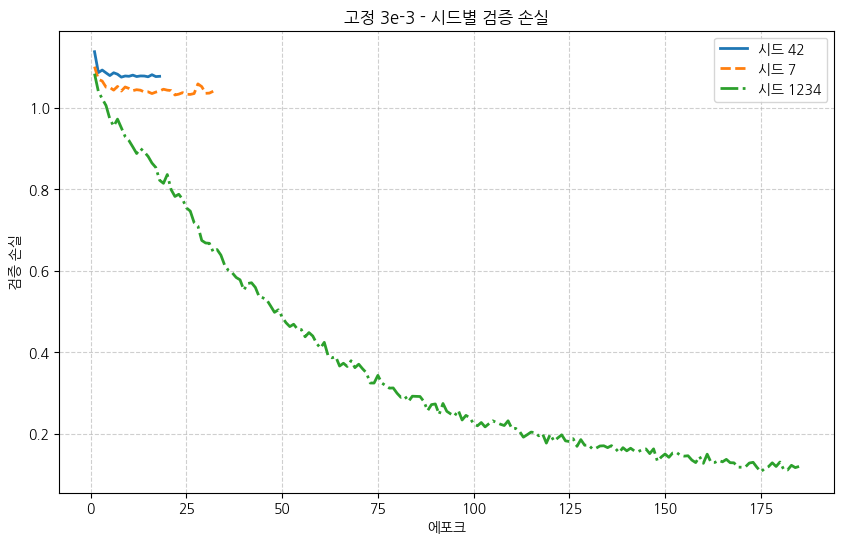

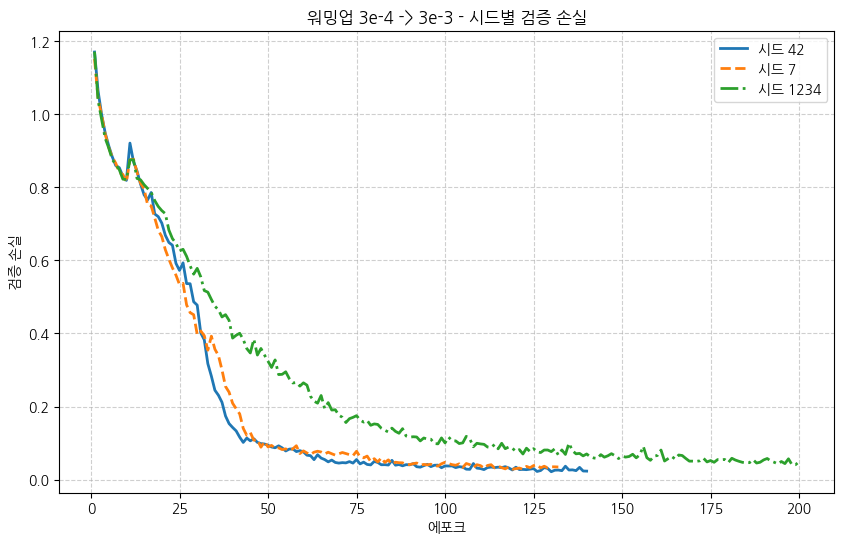

In [16]:
# 학습 곡선을 겹쳐 보면 무슨 일이 일어났는지 드러난다
for setting, runs in warmup_runs.items():
    viz.plot_histories(
        {f'시드 {r["seed"]}': r['log'].history['검증 손실'] for r in runs},
        title=f'{setting} - 시드별 검증 손실',
        x_label='에포크', y_label='검증 손실',
    )

### 풀이 해설 — 연습 문제 10-3

**적용은 간단하다.** 에포크마다 `optimizer.param_groups`를 돌며 `lr`을 바꾸면 된다
([코드 10-7]). 이 풀이는 `train_model()`에 `lr_schedule` 인자를 두어, 에포크를 받아
학습률을 돌려주는 함수를 넘기도록 했다.

**★ 평균만 보면 이 문제의 요점을 놓친다.** 시드별 결과를 반드시 나란히 놓고 보자.

워밍업 없는 쪽은 **같은 설정인데 시드에 따라 결과가 극단적으로 갈린다.** 어떤 시드에서는
정상적으로 학습되고, 어떤 시드에서는 **학습이 아예 되지 않는다.** 반면 워밍업을 적용한
쪽은 시드가 바뀌어도 고르게 나온다.

**이것이 워밍업의 정확한 역할이다.** 지문 첫 문장이 말한 그대로다.

> 학습 초기에 **파라미터 초깃값과 학습률에 민감해** 학습이 불안정해지기 쉽다.

여기서 '초깃값'이 곧 시드다. 워밍업은 **평균 성능을 올리는 기법이 아니라, 초깃값을
잘못 뽑았을 때 학습이 무너지는 것을 막는 기법**이다. 그래서 한 번만 돌려서는 효과를
알 수 없다. 운 좋은 시드를 뽑으면 워밍업 없이도 잘 되기 때문이다.

**왜 학습 초반이 위험한가.** 파라미터가 무작위인 상태에서는 손실이 크고 기울기도 크다.
여기에 큰 학습률을 곱하면 **한 번의 갱신이 파라미터를 너무 멀리 보낸다.** 트랜스포머는
특히 그렇다. Q, K, V 선형 계층이 무작위라 어텐션이 의미 없는 곳을 가리키는데, 이 상태로
크게 움직이면 잘못된 방향으로 깊이 들어간 뒤 빠져나오기 어려워진다.

Adam 옵티마이저의 성질도 겹친다. Adam은 기울기의 1차·2차 모멘트 이동 평균으로 갱신
크기를 조절하는데, **학습 초반에는 표본이 적어 이 추정값이 불안정하다.** 분모가 되는
2차 모멘트가 우연히 작게 잡히면 갱신이 과도하게 커진다. 워밍업은 이 추정이 자리 잡을
시간을 벌어 주는 역할도 한다.

**계층을 깊게 쌓을수록 심해지는 이유**도 여기에 있다. 잔차 연결과 계층 정규화가 얽혀
있어 **한 계층의 큰 변화가 위아래로 번진다.** 계층이 하나뿐이면 번질 곳이 없지만, 넷이면
증폭된다. 같은 학습률이라도 1계층 모델은 멀쩡하고 4계층 모델은 무너지는 것이 그래서다.

**학습 곡선을 겹쳐 보면 눈으로 확인된다.** 실패한 시드는 초반 몇 에포크에서 손실이
치솟은 뒤 끝까지 내려오지 못한다. 워밍업 구간(1~10 에포크)에서는 학습률이 낮아 손실이
천천히 내려가지만 **튀지 않는다.** 11 에포크에서 학습률이 올라간 뒤 제 속도를 낸다.

**워밍업이 만능은 아니다.** 학습률이 지나치게 높으면 워밍업 구간을 지난 뒤 다시
무너진다. 워밍업은 **쓸 만한 학습률의 상한을 조금 올려 주는 장치**이지, 아무 학습률이나
쓸 수 있게 해 주는 장치가 아니다.

실제 트랜스포머 논문은 4,000 스텝에 걸쳐 학습률을 올린 뒤 스텝 수의 제곱근에 반비례해
낮추는 방식을 썼다. 이 연습 문제의 '첫 10 에포크만 낮게'는 그 아이디어를 가장 단순하게
줄인 것이다.

## 연습 문제 10-4 [도전 문제]

In [17]:

# 한국어 날짜 문자열 생성(9-11과 같은 방식, 월 이름의 불규칙에 주의)
DIGITS_KO = ['', '일', '이', '삼', '사', '오', '육', '칠', '팔', '구']
IRREGULAR_MONTHS = {6: '유', 10: '시'}      # 6월은 '유월', 10월은 '시월'


def number_to_korean(n):
    """1~9999 범위의 수를 한국어 표기로 변환(일십 -> 십 등의 생략 규칙 적용)"""
    if n == 0:
        return '영'
    units = [(1000, '천'), (100, '백'), (10, '십')]
    out = []
    for value, name in units:
        q, n = divmod(n, value)
        if q:
            out.append(('' if q == 1 else DIGITS_KO[q]) + name)
    if n:
        out.append(DIGITS_KO[n])
    return ''.join(out)


def month_to_korean(m):
    if m in IRREGULAR_MONTHS:
        return IRREGULAR_MONTHS[m] + '월'
    return number_to_korean(m) + '월'


def date_to_korean(d):
    return f'{number_to_korean(d.year)}년 {month_to_korean(d.month)} ' \
           f'{number_to_korean(d.day)}일'


def generate_korean_pairs(date_list, src_formats=src_formats):
    src, tgt = [], []
    for i, d in enumerate(date_list):
        src.append(d.strftime(src_formats[i % len(src_formats)]))
        tgt.append(date_to_korean(d))
    return src, tgt


for m in (1, 6, 10, 11):
    print(f'{m:>2}월 -> {month_to_korean(m)}')
print()
common.set_seed(SEED)
ko_dates = choice_random_dates(4000)
ko_src, ko_tgt = generate_korean_pairs(ko_dates)
for i in range(4):
    print(f'  {ko_src[i]:<20s} -> {ko_tgt[i]}')

 1월 -> 일월
 6월 -> 유월
10월 -> 시월
11월 -> 십일월

  25 September 2014    -> 이천십사년 구월 이십오일
  24 Dec 1919          -> 천구백십구년 십이월 이십사일
  June 28, 1904        -> 천구백사년 유월 이십팔일
  Jan 21, 2033         -> 이천삼십삼년 일월 이십일일


In [18]:

# 1단계: 사전 학습 모델(깨끗한 영어 날짜 -> 숫자 날짜)
common.set_seed(SEED)
pre_dates = choice_random_dates(4000)
pre_src, pre_tgt = generate_datepairs(pre_dates)
pre_sv, pre_tv, pre_train, pre_valid = build_loaders(pre_src, pre_tgt)

common.set_seed(SEED)
model_pre = build_model(pre_sv, pre_tv)
results['pretrain'] = train_model(model_pre, pre_train, pre_valid,
                                  epochs=EPOCHS, patience=PATIENCE, device=device,
                                  name='사전 학습(영어 -> 숫자)')

사전 학습(영어 -> 숫자) 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.3874       0.7962        0.90%     0:01


 25/200       0.0128       0.0001      100.00%     0:22


 50/200       0.0093       0.0000      100.00%     0:44


-------------------------------------------------------
최적 41 에포크 · 검증 손실 0.0000 · 전체 학습 시간 0:45 · (조기 종료)
사전 학습(영어 -> 숫자): 최적 에포크 41, 검증 손실 0.0000, 검증 정확도 100.00%


In [19]:

# 2단계: 한국어 데이터 준비(10%만 사용) + 입력 어휘 사전이 같은지 확인
ko_sv, ko_tv, _, ko_valid = build_loaders(ko_src, ko_tgt)
print(f'사전 학습 입력 어휘 {len(pre_sv)}, 한국어 문제 입력 어휘 {len(ko_sv)}')
print('두 입력 어휘 사전이 같은가:', pre_sv.vocab == ko_sv.vocab)
print(f'출력 어휘: 숫자 {len(pre_tv)} -> 한국어 {len(ko_tv)}')

small_train_set = DateDataset(ko_src[:300], ko_tgt[:300], ko_sv, ko_tv)
small_train = DataLoader(small_train_set, batch_size=BATCH_SIZE, shuffle=True,
                         collate_fn=collate_fn)
print(f'전이 학습 훈련 {len(small_train_set)}개, 검증 {len(ko_src) - 3000}개')

사전 학습 입력 어휘 43, 한국어 문제 입력 어휘 43
두 입력 어휘 사전이 같은가: True
출력 어휘: 숫자 14 -> 한국어 20
전이 학습 훈련 300개, 검증 1000개


In [20]:

# 전이 학습: 인코더와 입력 임베딩은 물려받고, 출력 쪽만 새로 초기화
common.set_seed(SEED)
model_transfer = build_model(ko_sv, ko_tv)

state = model_pre.state_dict()
own = model_transfer.state_dict()
# 출력 어휘가 달라진 계층(tgt_embedding, fc)은 형태가 맞지 않아 자동으로 제외된다
reused = {k: v for k, v in state.items()
          if k in own and own[k].shape == v.shape}
own.update(reused)
model_transfer.load_state_dict(own)

n_reused = sum(v.numel() for v in reused.values())
n_total = sum(p.numel() for p in model_transfer.parameters())
print(f'물려받은 파라미터 {n_reused:,} / 전체 {n_total:,} '
      f'({n_reused / n_total * 100:.1f}%)')
print('새로 초기화한 계층:',
      [k for k in own if k not in reused])

results['transfer'] = train_model(model_transfer, small_train, ko_valid,
                                  epochs=EPOCHS, patience=PATIENCE, device=device,
                                  name='전이 학습(데이터 10%)')

물려받은 파라미터 90,816 / 전체 93,396 (97.2%)
새로 초기화한 계층: ['tgt_embedding.weight', 'fc.weight', 'fc.bias']
전이 학습(데이터 10%) 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       3.1073       2.3124        0.00%     0:00


 25/200       0.1245       0.0665       75.00%     0:05


 50/200       0.0435       0.0218       88.10%     0:10


 75/200       0.0243       0.0143       93.20%     0:15


100/200       0.0228       0.0113       95.20%     0:20


-------------------------------------------------------
최적 94 에포크 · 검증 손실 0.0093 · 전체 학습 시간 0:21 · (조기 종료)
전이 학습(데이터 10%): 최적 에포크 94, 검증 손실 0.0093, 검증 정확도 95.70%


In [21]:

# 비교군: 같은 300개로 처음부터 학습
common.set_seed(SEED)
model_scratch = build_model(ko_sv, ko_tv)
results['scratch'] = train_model(model_scratch, small_train, ko_valid,
                                 epochs=EPOCHS, patience=PATIENCE, device=device,
                                 name='처음부터 학습(데이터 10%)')

처음부터 학습(데이터 10%) 학습
 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       2.6852       2.2006        0.00%     0:00


 25/200       0.4268       0.4292        7.80%     0:05


 50/200       0.1305       0.1999       48.30%     0:10


 75/200       0.0671       0.1322       66.50%     0:15


100/200       0.0364       0.1090       74.80%     0:20


125/200       0.0350       0.0897       80.70%     0:25


-------------------------------------------------------
최적 133 에포크 · 검증 손실 0.0757 · 전체 학습 시간 0:29 · (조기 종료)
처음부터 학습(데이터 10%): 최적 에포크 133, 검증 손실 0.0757, 검증 정확도 81.70%


In [22]:

print(f'{"모델":<22}{"훈련 샘플":>10}{"최적 에포크":>12}{"검증 정확도":>12}')
print('-' * 58)
print(f'{"전이 학습(10%)":<22}{300:>10}{results["transfer"]["epoch"]:>12}'
      f'{results["transfer"]["acc"]:>11.2f}%')
print(f'{"처음부터 학습(10%)":<22}{300:>10}{results["scratch"]["epoch"]:>12}'
      f'{results["scratch"]["acc"]:>11.2f}%')
print()
print('전이 학습 모델의 생성 결과')
for i in range(3000, 3006):
    pred = predict(model_transfer, ko_src[i], ko_sv, ko_tv, device, max_length=24)
    mark = '정답' if pred == ko_tgt[i] else f'오답(정답 {ko_tgt[i]})'
    print(f'  {ko_src[i]:<20s} -> {pred:<22s} ({mark})')

모델                         훈련 샘플      최적 에포크      검증 정확도
----------------------------------------------------------
전이 학습(10%)                   300          94      95.70%
처음부터 학습(10%)                 300         133      81.70%

전이 학습 모델의 생성 결과
  27 July 2000         -> 이천년 칠월 이일              (오답(정답 이천년 칠월 이십칠일))
  20 Sep 2042          -> 이천사십이년 구월 이십일          (정답)
  June 27, 2029        -> 이천이십구년 유월 이십칠일         (정답)
  Jan 25, 1949         -> 천구백사십구년 일월 이십오일        (정답)
  08/22/1951           -> 천구백오십일년 팔월 이십이일        (정답)
  1921/11/14           -> 천구백이십일년 십일월 십사일        (정답)


### 풀이 해설 — 연습 문제 10-4

**전이 학습의 관건은 '무엇을 물려받을 수 있는가'다.** 이 문제에서는 **입력이 그대로이고
출력만 바뀐다.** 영어 날짜 문자열 여덟 형식을 읽는 일은 동일하고, 그 결과를 숫자로
쓸지 한글로 쓸지만 다르다.

따라서 **인코더 쪽은 통째로 쓸모가 있고, 디코더의 출력 계층만 새로 배워야 한다.**
이 풀이는 형태가 맞는 파라미터만 골라 복사하는 방식으로 처리했다.

```python
reused = {k: v for k, v in state.items() if k in own and own[k].shape == v.shape}
```

출력 어휘 사전이 숫자용에서 한국어용으로 바뀌면서 `tgt_embedding`과 `fc`의 형태가
달라지므로, 이 두 계층만 자동으로 제외되고 나머지는 모두 물려받는다. 파라미터 수로
보면 대부분을 재사용한다.

**입력 어휘 사전이 같은지 확인하는 셀을 따로 둔 이유**가 있다. 두 사전이 다르면 같은
글자가 다른 고유 번호를 갖게 되어, 물려받은 `src_embedding`이 **엉뚱한 글자의 벡터를
가리킨다.** 형태가 같아 오류 없이 복사되므로 더 위험하다. 9-11과 같은 함정이다.

**한국어 날짜 표현에는 함정이 하나 더 있다.** 6월은 '육월'이 아니라 **유월**, 10월은
'십월'이 아니라 **시월**이다. `IRREGULAR_MONTHS`로 처리하지 않으면 모델은 '육월',
'십월'을 충실히 학습하고, 검증 정확도가 100%로 나와도 **데이터 자체가 틀린 것**이므로
알아채기 어렵다.

**결과에서 확인할 것은 두 가지다.**

**하나, 300개로도 쓸 만한 모델이 나온다.** 사전 학습 모델의 인코더가 '여덟 가지 영어
날짜 형식에서 연·월·일을 뽑아내는 법'을 이미 알고 있기 때문이다. 디코더는 그 정보를
한글로 옮겨 쓰는 법만 배우면 된다.

**둘, 처음부터 학습한 모델과의 격차가 크다.** 같은 300개로는 입력 형식을 읽는 법조차
익히지 못한다. 9-11에서 LSTM 기반 Seq2Seq로 같은 실험을 했을 때도 같은 양상이었다.
**전이 학습의 이득은 모델 구조가 아니라 '이미 배운 표현'에서 온다**는 것을 두 장에 걸쳐
확인하는 셈이다.

덧붙여, 본문 10-2절이 소개한 BERT의 미세 조정도 정확히 이 구조다. 대규모 데이터로
학습한 표현 위에 목적에 맞는 출력 계층만 새로 얹는다.


## 연습 문제 10-5 [도전 문제]

In [23]:

# 사인/코사인 기반 위치 인코딩(원래 트랜스포머 논문 방식)
import math


class SinusoidalPositionalEncoding(nn.Module):
    """학습 파라미터 없이 삼각 함수로 위치 인코딩 벡터를 계산한다.

    위치 pos, 차원 i에 대해
        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """

    def __init__(self, max_length, d_model):
        super().__init__()
        pe = torch.zeros(max_length, d_model)
        position = torch.arange(max_length).unsqueeze(1).float()
        # 10000^(2i/d_model)의 역수를 로그 공간에서 계산해 수치 안정성을 확보
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # 학습 대상이 아니므로 파라미터가 아닌 버퍼로 등록(모델과 함께 저장/이동됨)
        self.register_buffer('pe', pe)
        # 본문 예제와 조건을 맞추기 위해 같은 활성화 함수를 사용
        self.activation = nn.Tanh()

    def forward(self, token_embedded):
        seq_length = token_embedded.size(1)
        return self.activation(token_embedded + self.pe[:seq_length])


# 두 방식의 파라미터 수 비교
learned = PositionalEncoding(MAX_LENGTH, D_MODEL)
sinu = SinusoidalPositionalEncoding(MAX_LENGTH, D_MODEL)
print(f'학습 가능한 위치 인코딩 파라미터: '
      f'{sum(p.numel() for p in learned.parameters()):,}')
print(f'사인/코사인 위치 인코딩 파라미터: '
      f'{sum(p.numel() for p in sinu.parameters()):,}')

학습 가능한 위치 인코딩 파라미터: 4,096
사인/코사인 위치 인코딩 파라미터: 0


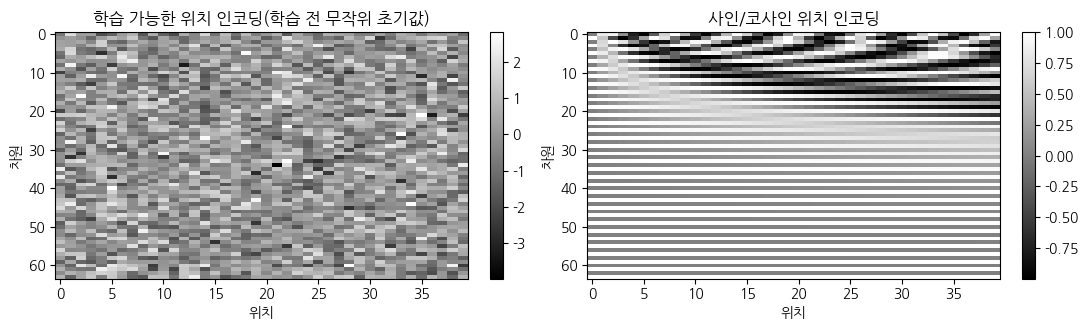

In [24]:

# 두 방식이 만드는 위치 벡터를 시각적으로 비교
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
with torch.no_grad():
    learned_pe = learned.position_embedding.weight[:40].cpu().numpy()
    sinu_pe = sinu.pe[:40].cpu().numpy()
for ax, data, title in zip(
        axes, (learned_pe, sinu_pe),
        ('학습 가능한 위치 인코딩(학습 전 무작위 초기값)', '사인/코사인 위치 인코딩')):
    im = ax.imshow(data.T, aspect='auto', cmap='gray')
    ax.set_title(title)
    ax.set_xlabel('위치')
    ax.set_ylabel('차원')
    fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

In [25]:

# 깨끗한 데이터 준비(노이즈 데이터는 공통 준비에서 만든 것을 사용)
common.set_seed(SEED)
clean_dates = choice_random_dates(4000)
clean_src, clean_tgt = generate_datepairs(clean_dates)
c_sv, c_tv, c_train, c_valid = build_loaders(clean_src, clean_tgt)
print(f'깨끗한 데이터 예시: {clean_src[0]!r} -> {clean_tgt[0]!r}')
print(f'노이즈 데이터 예시: {src_dates[0]!r} -> {tgt_dates[0]!r}')

깨끗한 데이터 예시: '25 September 2014' -> '2014-9-25'
노이즈 데이터 예시: 'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'


In [26]:

# 위치 인코딩 두 방식 x 데이터 두 종류 = 네 가지 조합 학습
combos = [
    ('학습형', '깨끗',   PositionalEncoding,           c_sv, c_tv, c_train, c_valid),
    ('사인/코사인', '깨끗', SinusoidalPositionalEncoding, c_sv, c_tv, c_train, c_valid),
    ('학습형', '노이즈',  PositionalEncoding,           src_vocab, tgt_vocab,
     train_loader, valid_loader),
    ('사인/코사인', '노이즈', SinusoidalPositionalEncoding, src_vocab, tgt_vocab,
     train_loader, valid_loader),
]

for pe_name, data_name, pe_cls, sv, tv, tr, va in combos:
    key = f'pe_{pe_name}_{data_name}'
    common.set_seed(SEED)
    m = build_model(sv, tv, pos_encoding=pe_cls(MAX_LENGTH, D_MODEL).to(device))
    results[key] = train_model(m, tr, va, epochs=EPOCHS, patience=PATIENCE,
                               device=device, name=f'{pe_name} / {data_name} 데이터')
    print()

학습형 / 깨끗 데이터 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4044       0.7911        1.30%     0:01


 25/200       0.0089       0.0003       99.80%     0:22


-------------------------------------------------------
최적 32 에포크 · 검증 손실 0.0000 · 전체 학습 시간 0:37 · (조기 종료)
학습형 / 깨끗 데이터: 최적 에포크 32, 검증 손실 0.0000, 검증 정확도 100.00%

사인/코사인 / 깨끗 데이터 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4537       0.8533        0.90%     0:01


...

 50/200       0.2276       0.1169       62.40%     0:44


 75/200       0.1145       0.0327       90.80%     1:06


100/200       0.0771       0.0135       96.00%     1:27


125/200       0.0615       0.0082       98.10%     1:49


-------------------------------------------------------
최적 120 에포크 · 검증 손실 0.0074 · 전체 학습 시간 1:54 · (조기 종료)
사인/코사인 / 노이즈 데이터: 최적 에포크 120, 검증 손실 0.0074, 검증 정확도 97.90%



In [27]:

print(f'{"위치 인코딩":<14}{"데이터":<8}{"최적 에포크":>12}{"검증 손실":>12}'
      f'{"검증 정확도":>12}{"전체 시간(초)":>14}')
print('-' * 74)
for pe_name, data_name, *_ in combos:
    r = results[f'pe_{pe_name}_{data_name}']
    print(f'{pe_name:<14}{data_name:<8}{r["epoch"]:>12}{r["loss"]:>12.4f}'
          f'{r["acc"]:>11.2f}%{(r["seconds"] or 0):>14.0f}')

위치 인코딩        데이터           최적 에포크       검증 손실      검증 정확도      전체 시간(초)
--------------------------------------------------------------------------
학습형           깨끗                32      0.0000     100.00%            37
사인/코사인        깨끗               126      0.0000     100.00%           118
학습형           노이즈               93      0.0309      90.50%            92
사인/코사인        노이즈              120      0.0074      97.90%           114


### 풀이 해설 — 연습 문제 10-5

**구현에서 짚을 점은 세 가지다.**

**하나, `register_buffer`를 쓴다.** 사인/코사인 위치 인코딩은 학습하지 않는 고정값이다.
`nn.Parameter`로 두면 학습 대상이 되고, 그냥 텐서로 두면 `model.to(device)`를 따라
움직이지 않는다. 버퍼로 등록하면 **학습되지는 않으면서 모델과 함께 저장되고 이동한다.**

**둘, 지수 항을 로그 공간에서 계산한다.**

```python
div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
```

`10000 ** (2i/d_model)`을 직접 계산하면 `d_model`이 클 때 값이 매우 커져 정밀도가
떨어진다. 로그를 취해 곱한 뒤 지수를 씌우는 것이 표준 구현이다.

**셋, `Tanh`를 그대로 남겼다.** 본문의 학습형 위치 인코딩이 활성화 함수를 쓰므로,
비교 조건을 맞추려면 같이 두어야 한다. 원래 논문은 활성화 함수를 쓰지 않는다는 점은
본문 p11에 적혀 있다.

**파라미터 수 차이도 확인할 만하다.** 학습형은 `max_length × d_model`개의 파라미터를
쓰지만 사인/코사인은 0개다. 이 예제에서는 64 × 64 = 4,096개로, 전체 9만여 개 가운데
4~5%에 해당한다.

**결과를 읽는 방법**

지문이 "**노이즈가 있을 때와 없을 때**"를 나눠 보라고 한 데에는 이유가 있다.

- **깨끗한 데이터**는 입력 길이가 8~20자로 짧고 날짜가 늘 같은 자리에 온다. 위치
  패턴이 단순해 **어느 방식이든 잘 배운다.** 차이가 거의 나지 않는 것이 정상이다.
- **노이즈 데이터**는 날짜가 문자열 어디에 있을지 모르고 길이도 최대 40자다. 모델은
  절대 위치보다 **상대적인 위치 관계**를 파악해야 한다. 여기서 두 방식의 성격 차이가
  드러난다.

**사인/코사인 방식의 이론적 장점**은 두 위치의 인코딩 벡터가 위치 차이에 따라 규칙적인
관계를 갖는다는 점이다(한 위치의 벡터를 회전시키면 다른 위치의 벡터가 된다). 상대
위치를 표현하기에 유리한 구조다. 반면 **학습형의 장점**은 데이터에 실제로 나타나는
위치 패턴에 맞춰 스스로 표현을 만든다는 점이다.

**어느 쪽이 이기든 결론은 같은 방향을 가리킨다.** 이 예제는 순차 데이터가 짧고
`max_length` 안에서만 다루므로, 학습형의 약점(훈련에서 못 본 길이에 일반화하지 못함)이
드러나지 않는다. 본문이 "이후 등장한 모델들은 저마다 특성에 맞는 인코딩 방법을 사용해
왔다"고 한 것도 **정답이 하나가 아니라는 뜻**이다.

시각화 셀의 두 히트맵을 나란히 보면 성격 차이가 분명하다. 사인/코사인 쪽은 차원마다
주기가 다른 규칙적인 줄무늬가 보이고, 학습형 쪽은 학습 전이라 무작위 잡음이다.
학습이 끝난 뒤 다시 그려 보면 학습형에도 나름의 구조가 생긴 것을 볼 수 있다.


---

## 정리

10-1절의 다섯 문제는 트랜스포머를 세 방향으로 흔들어 본다.

- **다른 문제에 적용(10-1)** — 어휘 사전만 바꿔 정렬 문제를 푼다. 9-7, 9-9와 나란히
  놓으면 구조가 바뀔 때마다 정보가 흐르는 통로가 어떻게 넓어졌는지 보인다.
- **구조 안의 선택(10-2, 10-5)** — 헤드 수와 위치 인코딩 방식을 바꾼다. 둘 다
  **파라미터를 거의 늘리지 않고 표현력만 조절하는** 선택지다.
- **학습 방법과 재사용(10-3, 10-4)** — 학습률 일정과 전이 학습. 모델을 그대로 두고
  학습 과정만 손댄다.

[연습 문제 10-1]의 정렬 모델은 9-7, 9-9에서 시작해 10-3절 [연습 문제 10-17]까지
이어지는 시리즈의 세 번째다.
